In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import joblib
import os

In [2]:

from google.colab import drive
drive.mount('/content/drive')

# 1. Tải dữ liệu
file_path = '/content/drive/My Drive/Colab Notebooks/supermarket_sales.csv'
df = pd.read_csv(file_path, parse_dates=['Order_Date']) # Chuyển đổi kiểu dữ liệu ngày
df = df.sort_values('Order_Date') # Sắp xếp dữ liệu theo thời gian


# 2.Đọc file chưa dữ liệu
print("==== THÔNG TIN DỮ LIỆU ====")

print(df.head())

df.info()

df.describe()


Mounted at /content/drive
==== THÔNG TIN DỮ LIỆU ====
   Order_ID Order_Date Region Country      Sales_Rep    Team Customer_ID  \
0      4971 2021-01-01  North     USA      David Lee  Team C       C3971   
1      2347 2021-01-02  South  Brazil  Alice Johnson  Team B       C1347   
2      2588 2021-01-02  South  Brazil   Maria Garcia  Team C       C1588   
3      5092 2021-01-02   East   China   Priya Sharma  Team B       C4092   
4      1182 2021-01-02  North  Canada      David Lee  Team A       C0182   

  Customer_Segment Product_Category   Product_Name        Stage  Units_Sold  \
0        Corporate        Furniture   Office Chair          Won           6   
1              SME       Appliances  Microwave Max  Opportunity           2   
2           Retail       Appliances   Refrigerator  Opportunity           5   
3           Retail       Appliances  Microwave Max  Opportunity           5   
4           Retail      Electronics   Smartphone Z         Lost           0   

   Revenue  Ta

,Order_ID,Order_Date,Units_Sold,Revenue,Target,Deal_Size
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3500.500000,2023-01-03 09:05:45.600000,2.818400,502.390000,994.572000,639.007800
min,1001.000000,2021-01-01 00:00:00,0.000000,0.000000,-193.000000,0.000000
25%,2250.750000,2022-01-13 00:00:00,0.000000,0.000000,567.000000,0.000000
50%,3500.500000,2023-01-05 12:00:00,2.000000,347.500000,914.000000,556.000000
75%,4750.250000,2023-12-21 06:00:00,5.000000,728.000000,1427.000000,1129.000000
max,6000.000000,2024-12-30 00:00:00,10.000000,1999.000000,2461.000000,1999.000000
std,1443.520003,NaN,2.922453,555.072392,556.665335,598.863616


In [ ]:
# Tổng số dòng thiếu
missing_rows = df.isnull().any(axis=1).sum()
print("Tổng số dòng thiếu: ",missing_rows)
# Tổng số dòng trùng lặp
duplicate_rows = df.duplicated().sum()
print("Tổng số dòng trùng lặp: ",duplicate_rows)


Tổng số dòng thiếu:  0
Tổng số dòng trùng lặp:  0


In [3]:

# Chuyển đổi Order_Date từ datetime sang numeric
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Day'] = df['Order_Date'].dt.day


# Xóa các cột không cần thiết
# =============================
cols_to_drop = ["Order_ID", "Customer_ID", "Product_Name","Order_Date"]
df = df.drop(columns=cols_to_drop, errors='ignore')

print(df.head());

  Region Country      Sales_Rep    Team Customer_Segment Product_Category  \
0  North     USA      David Lee  Team C        Corporate        Furniture   
1  South  Brazil  Alice Johnson  Team B              SME       Appliances   
2  South  Brazil   Maria Garcia  Team C           Retail       Appliances   
3   East   China   Priya Sharma  Team B           Retail       Appliances   
4  North  Canada      David Lee  Team A           Retail      Electronics   

         Stage  Units_Sold  Revenue  Target  Deal_Size  Order_Year  \
0          Won           6     1662    1447       1665        2021   
1  Opportunity           2      464     875        928        2021   
2  Opportunity           5      132     277        264        2021   
3  Opportunity           5      610    1080       1220        2021   
4         Lost           0        0     854          0        2021   

   Order_Month  Order_Day  
0            1          1  
1            1          2  
2            1          2  
3   

In [4]:
# 3. Tiền xử lý dữ liệu và Chuẩn bị biến mục tiêu (Target Variable)
# Mã hóa biến mục tiêu 'Stage'
le = LabelEncoder()
df['Stage'] = le.fit_transform(df['Stage'])# =============================

#Kiểm tra dữ liệu
print(df.head());

  Region Country      Sales_Rep    Team Customer_Segment Product_Category  \
0  North     USA      David Lee  Team C        Corporate        Furniture   
1  South  Brazil  Alice Johnson  Team B              SME       Appliances   
2  South  Brazil   Maria Garcia  Team C           Retail       Appliances   
3   East   China   Priya Sharma  Team B           Retail       Appliances   
4  North  Canada      David Lee  Team A           Retail      Electronics   

   Stage  Units_Sold  Revenue  Target  Deal_Size  Order_Year  Order_Month  \
0      2           6     1662    1447       1665        2021            1   
1      1           2      464     875        928        2021            1   
2      1           5      132     277        264        2021            1   
3      1           5      610    1080       1220        2021            1   
4      0           0        0     854          0        2021            1   

   Order_Day  
0          1  
1          2  
2          2  
3          2  

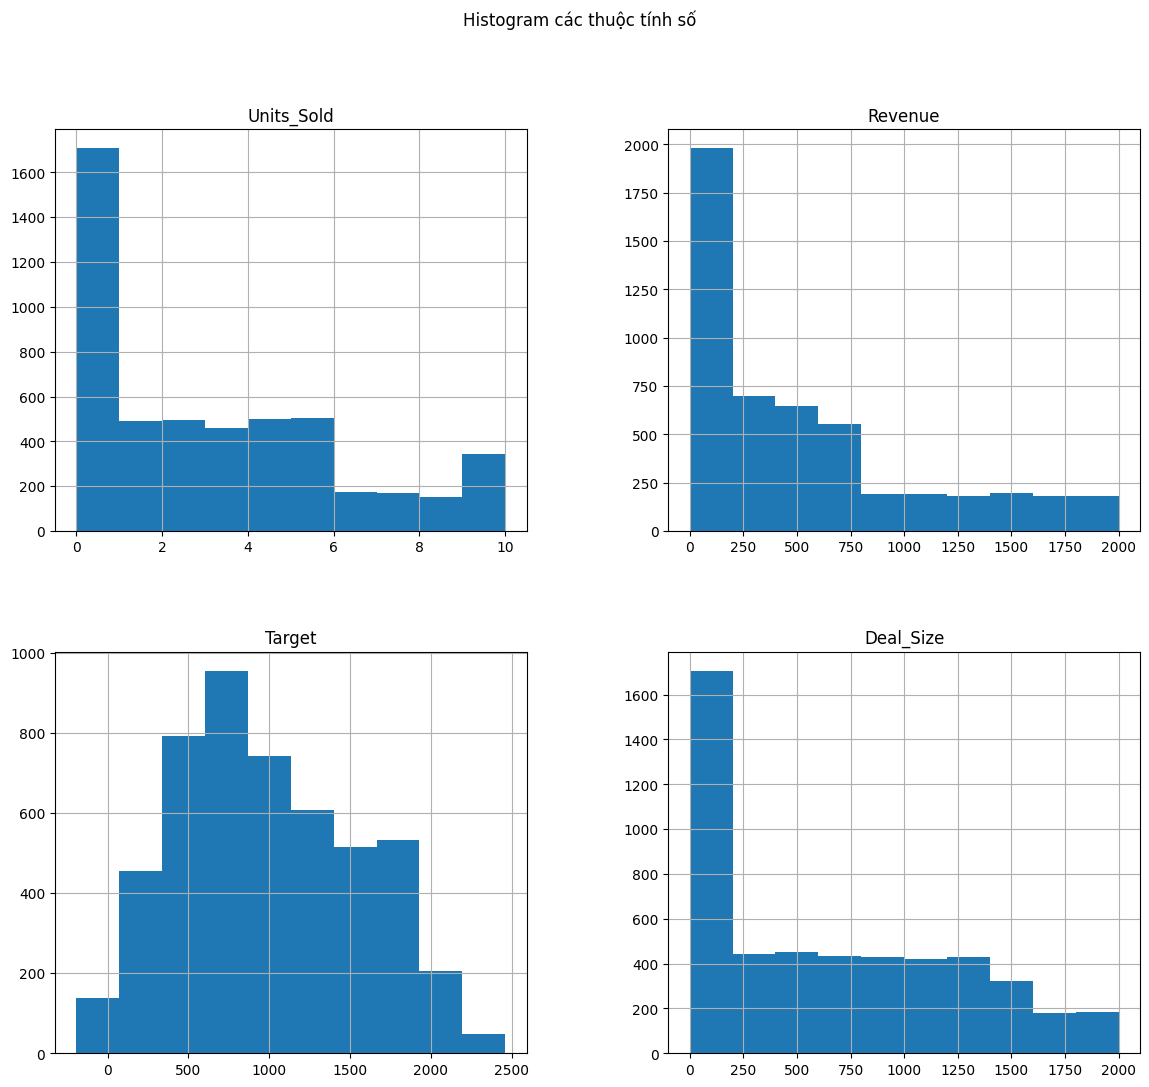

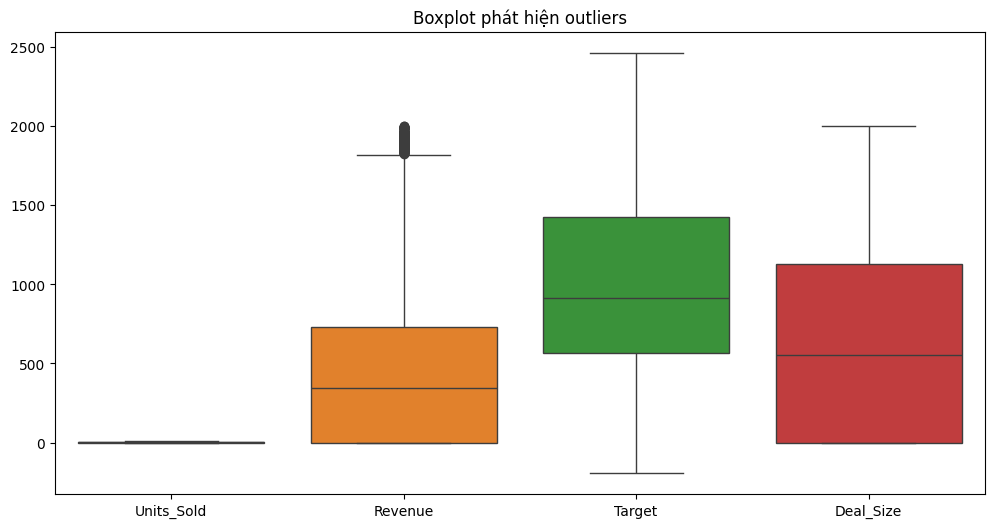

In [5]:
# =============================
# Trực quan hóa dữ liệu số
# =============================

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Stage', errors='ignore')

# Histogram cho mỗi cột số
df[numeric_cols].hist(figsize=(14, 12))
plt.suptitle("Histogram các thuộc tính số")
plt.show()

# Boxplot để kiểm tra outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot phát hiện outliers")
plt.show()


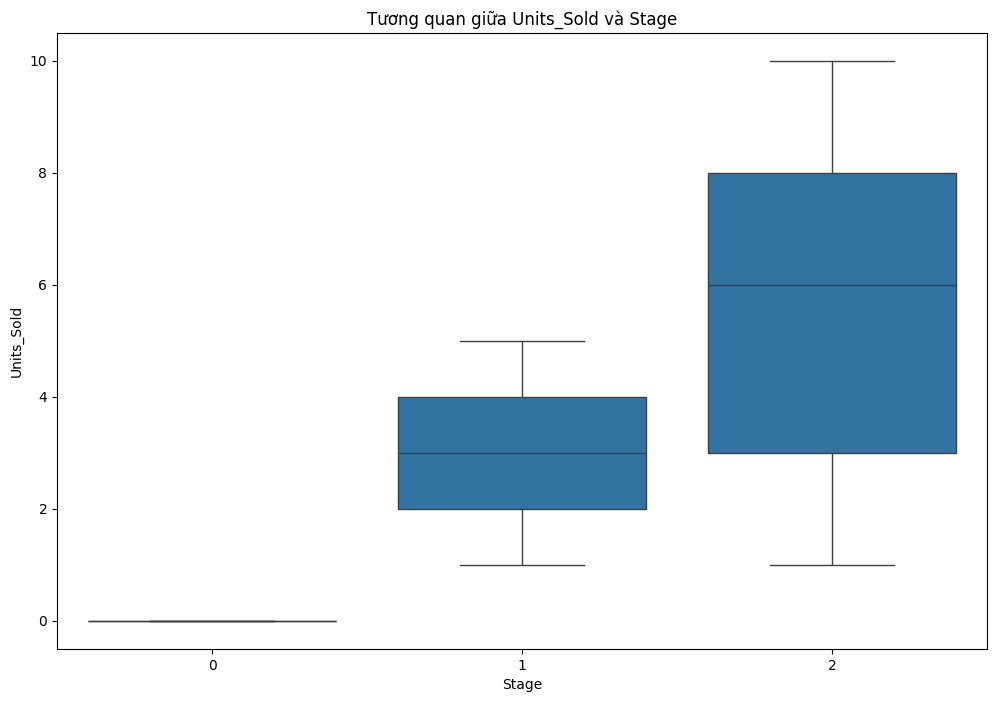

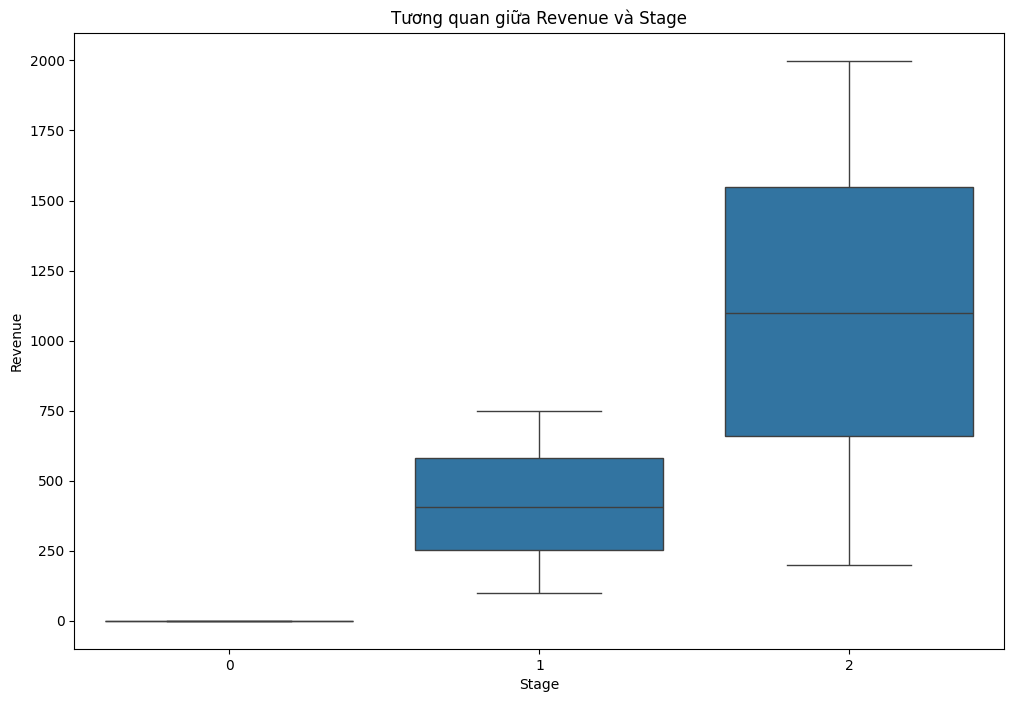

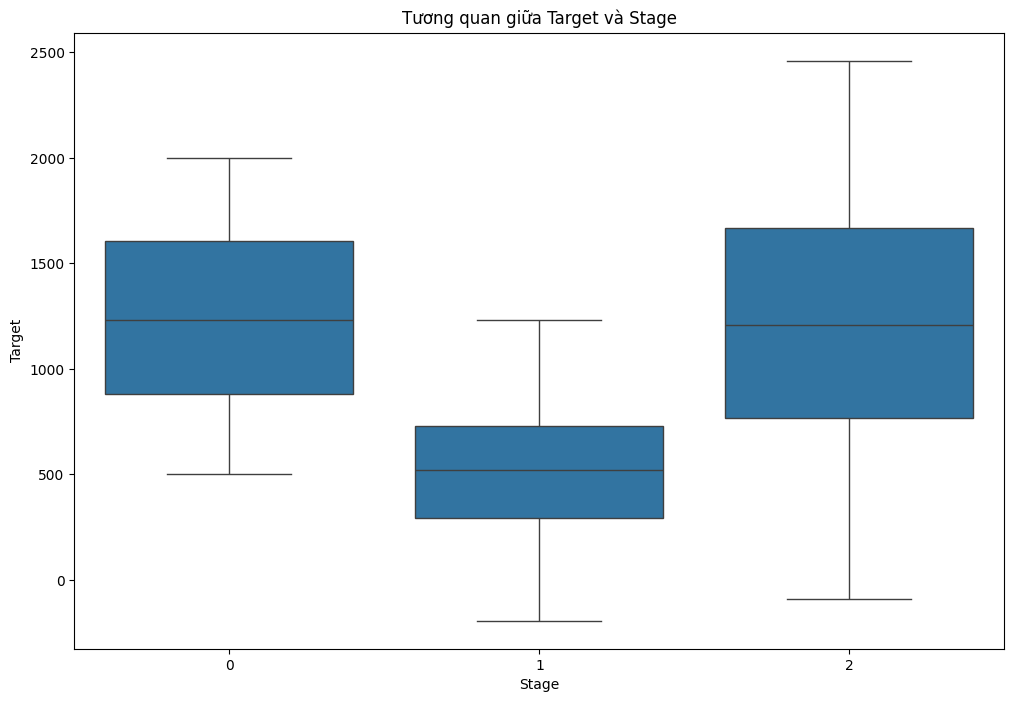

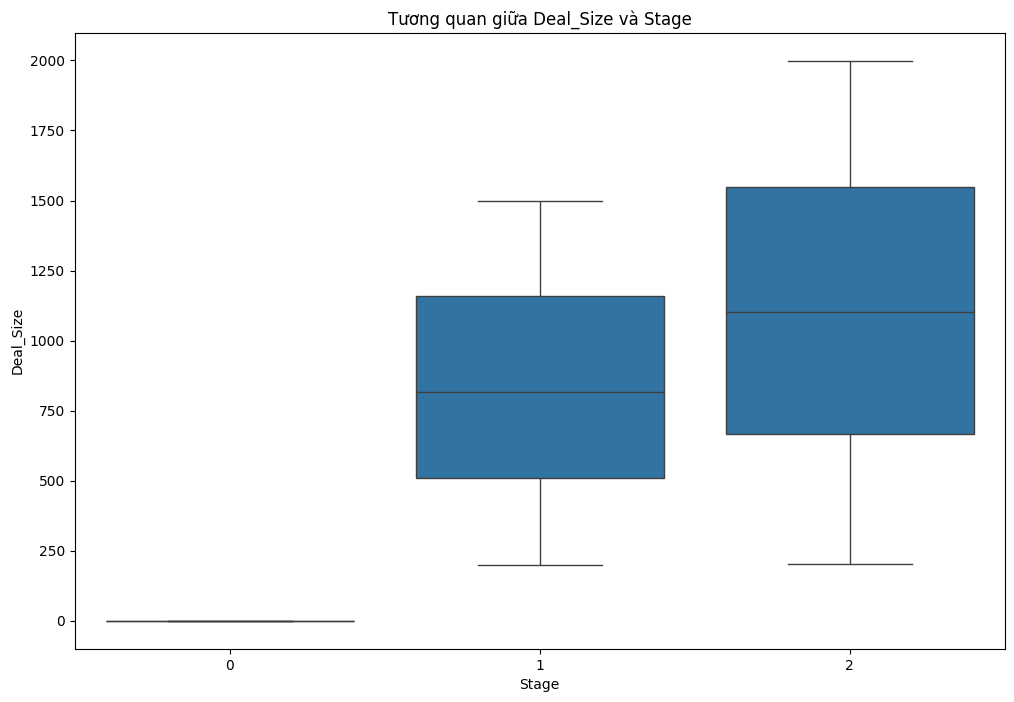

In [6]:
# Phân tích mối quan hệ giữa các biến số và mục tiêu

target = "Stage"

# Lấy các cột số hiện tại
num_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Xóa biến mục tiêu khỏi danh sách
if target in num_features:
    num_features.remove(target)

# Vẽ từng biểu đồ tách riêng
for col in num_features:
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df, x=target, y=col)
    plt.title(f"Tương quan giữa {col} và {target}")
    plt.xlabel("Stage")
    plt.ylabel(col)
    plt.show()


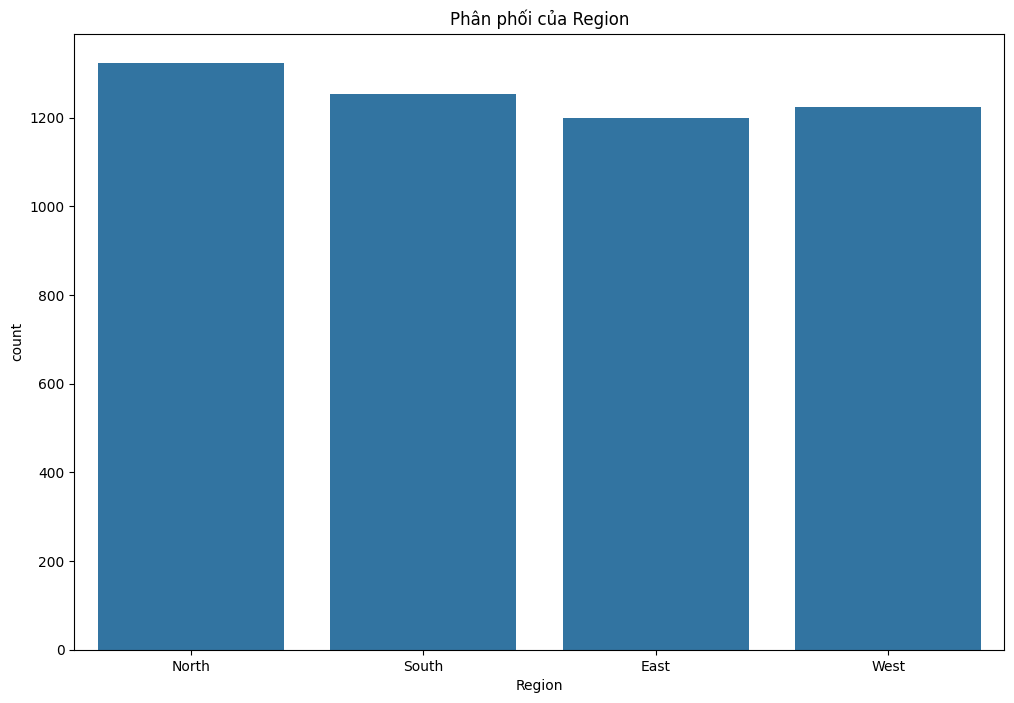

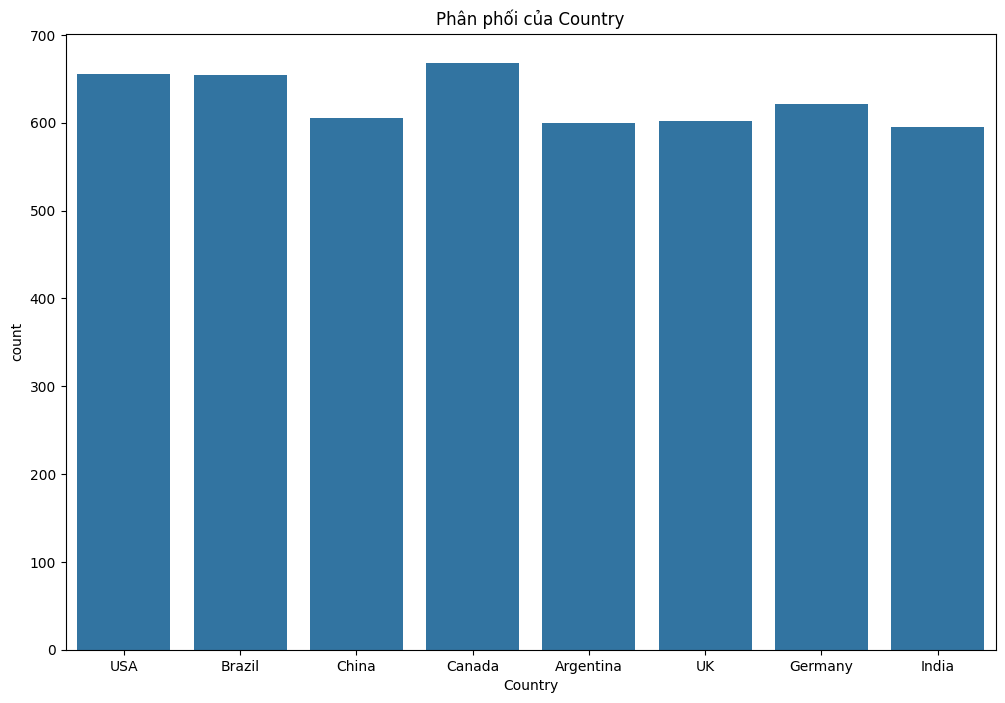

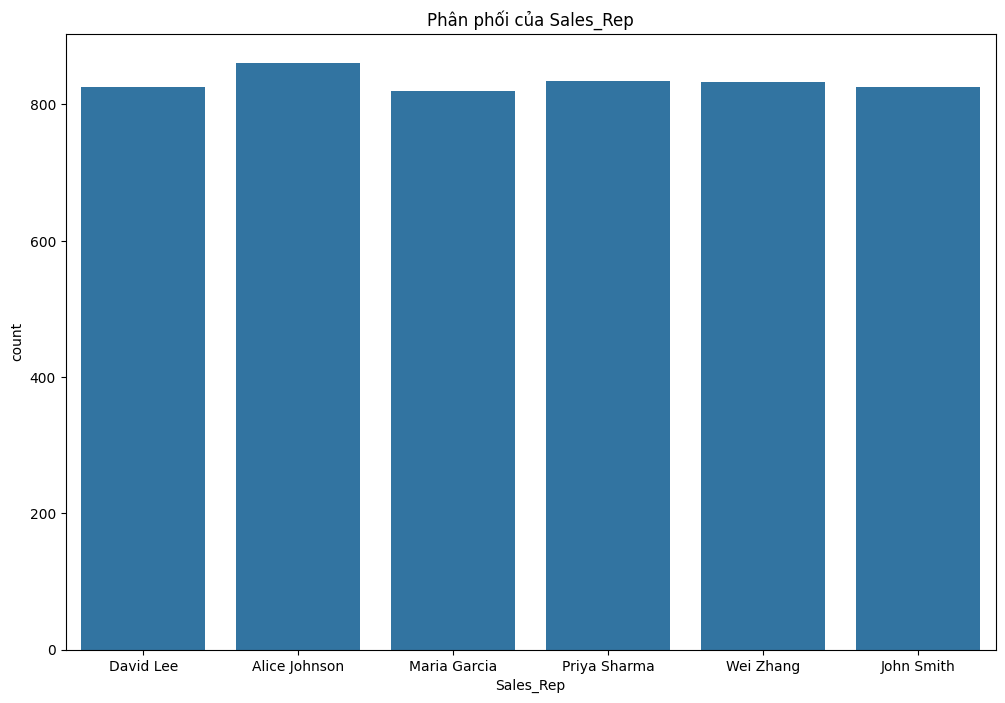

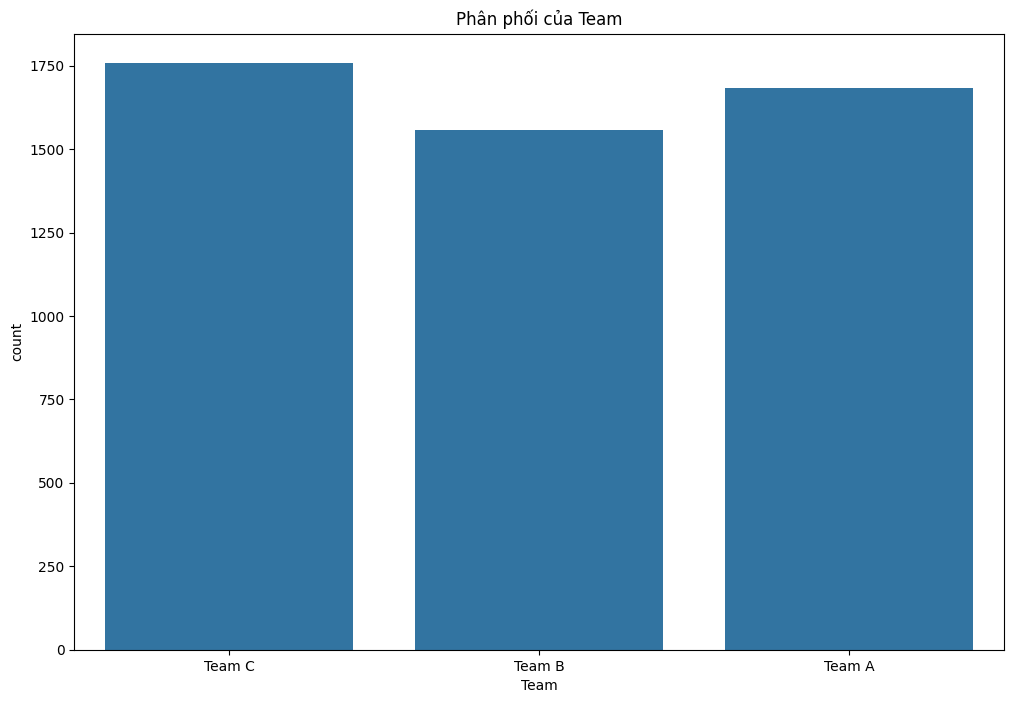

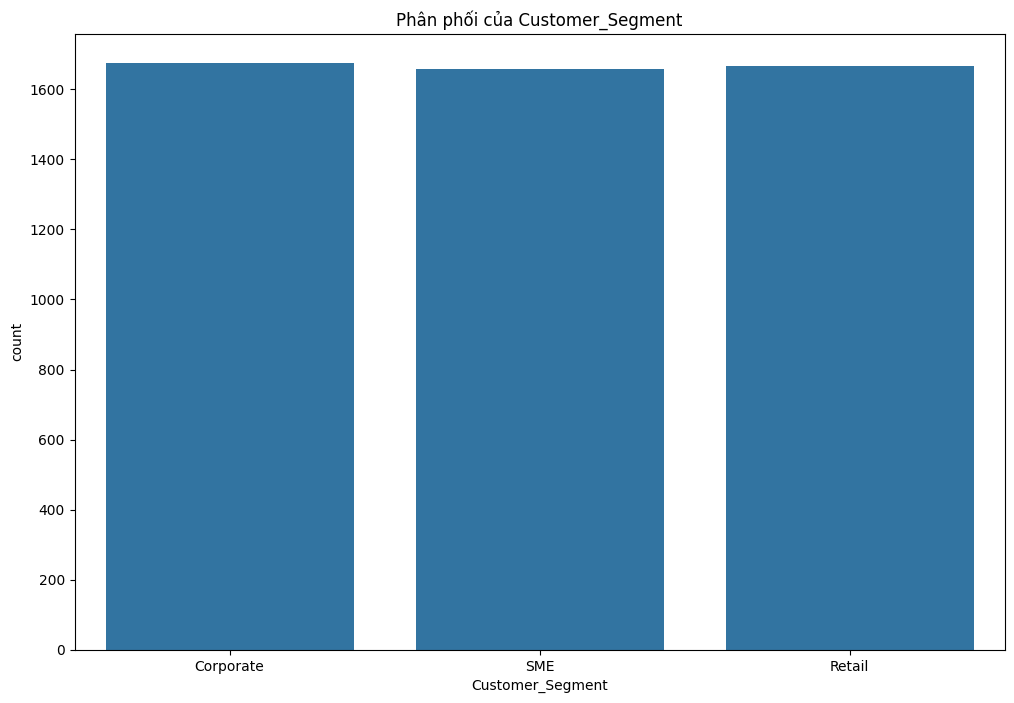

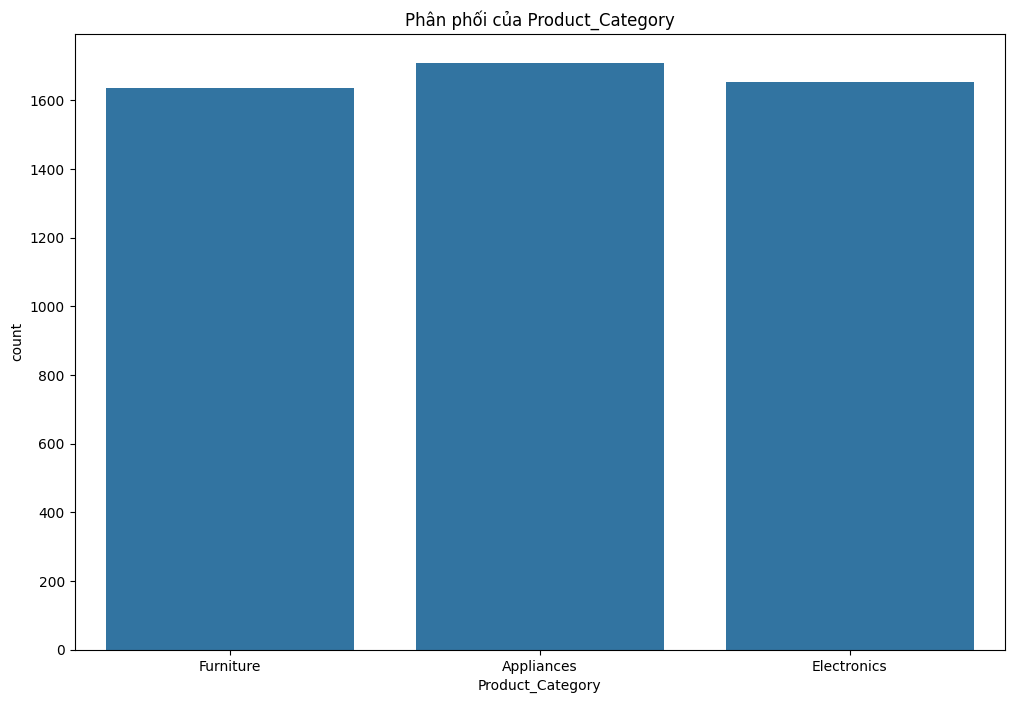

In [7]:
# Phân tích các thuộc tính phân loại (cat_features)
cat_features = df.select_dtypes(include=["object"]).columns.tolist()

for col in cat_features:
    plt.figure(figsize=(12,8))
    sns.countplot(data=df, x=col)
    plt.title(f"Phân phối của {col}")
    plt.show()


Các cột phân loại cần vẽ: ['Region', 'Country', 'Sales_Rep', 'Team', 'Customer_Segment', 'Product_Category']


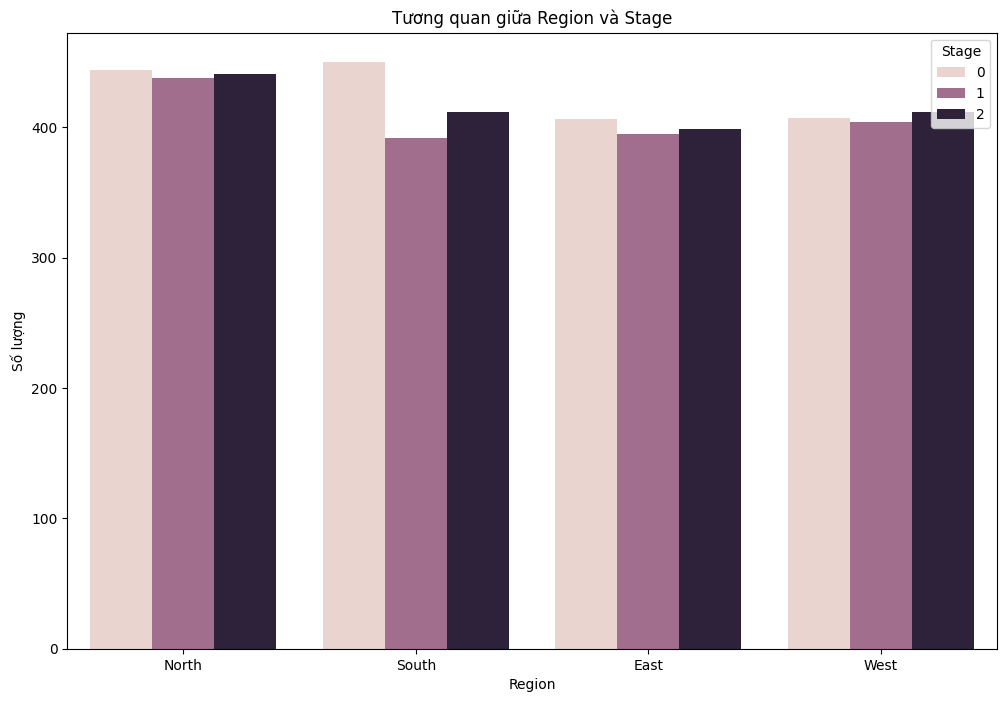

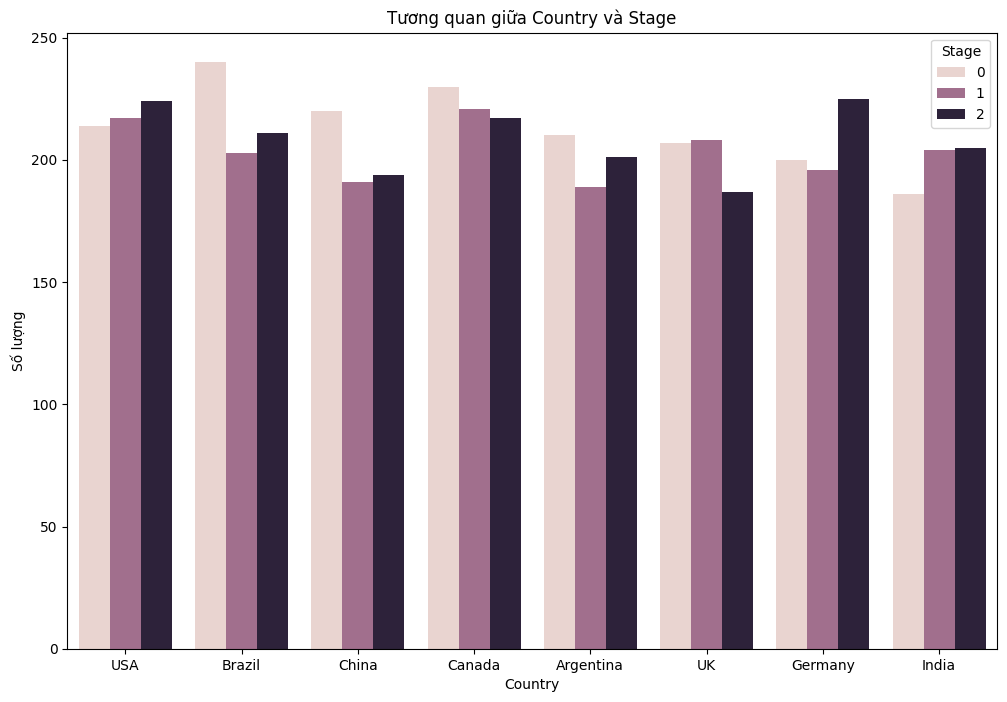

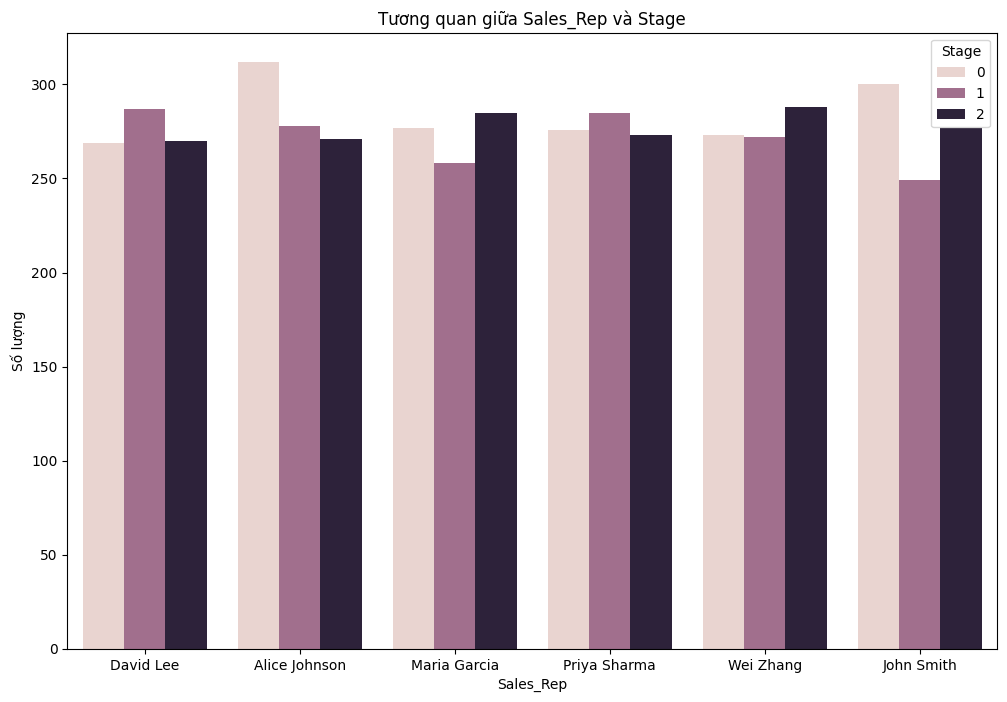

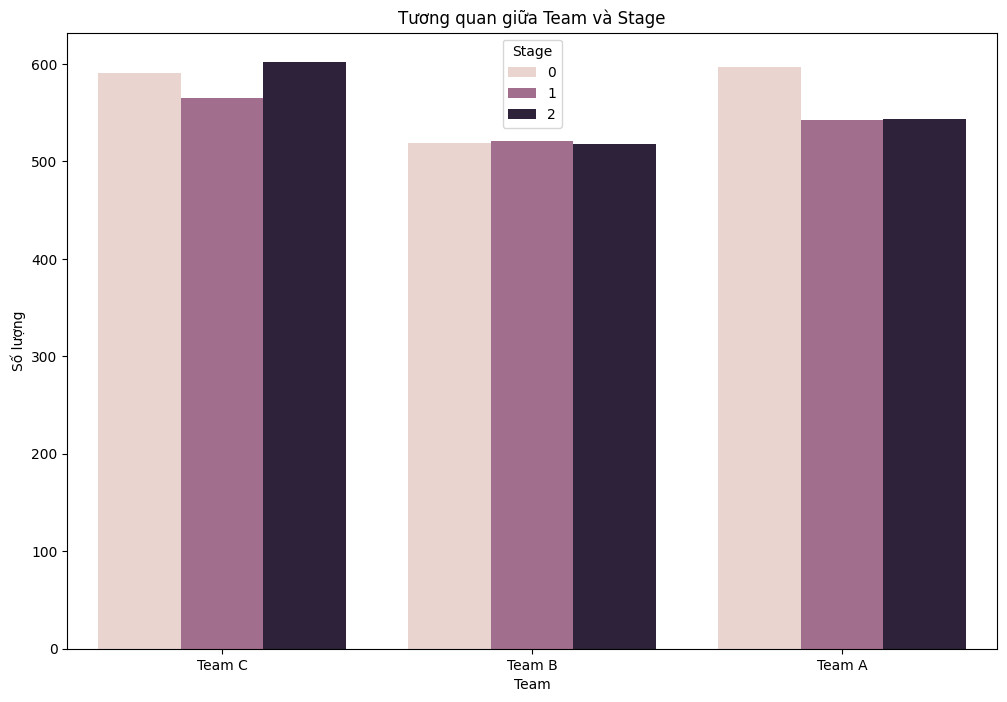

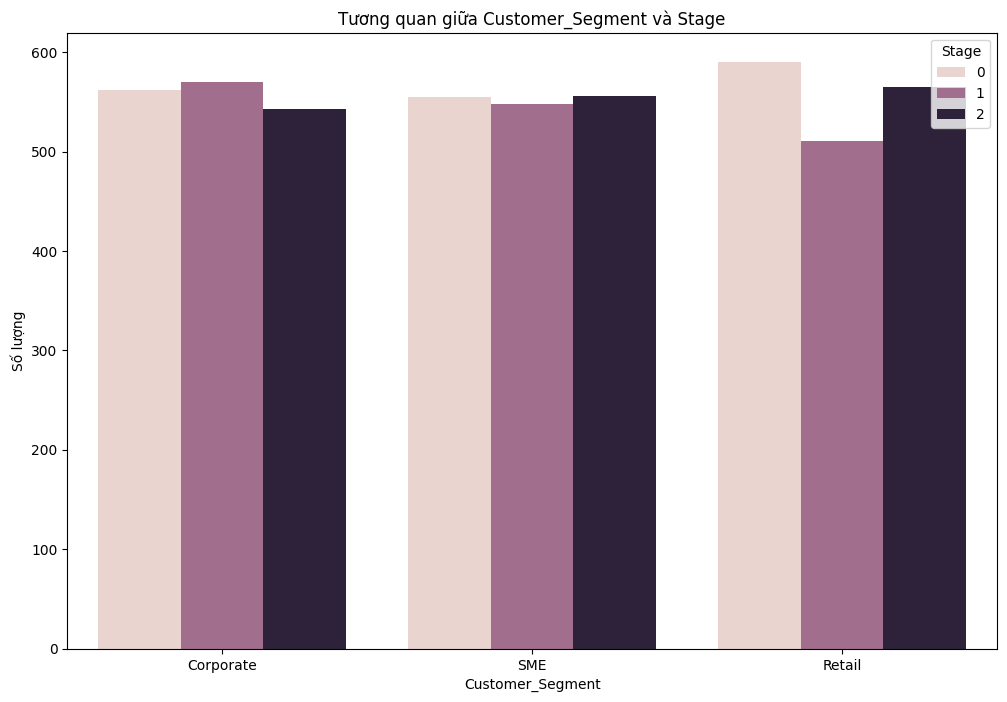

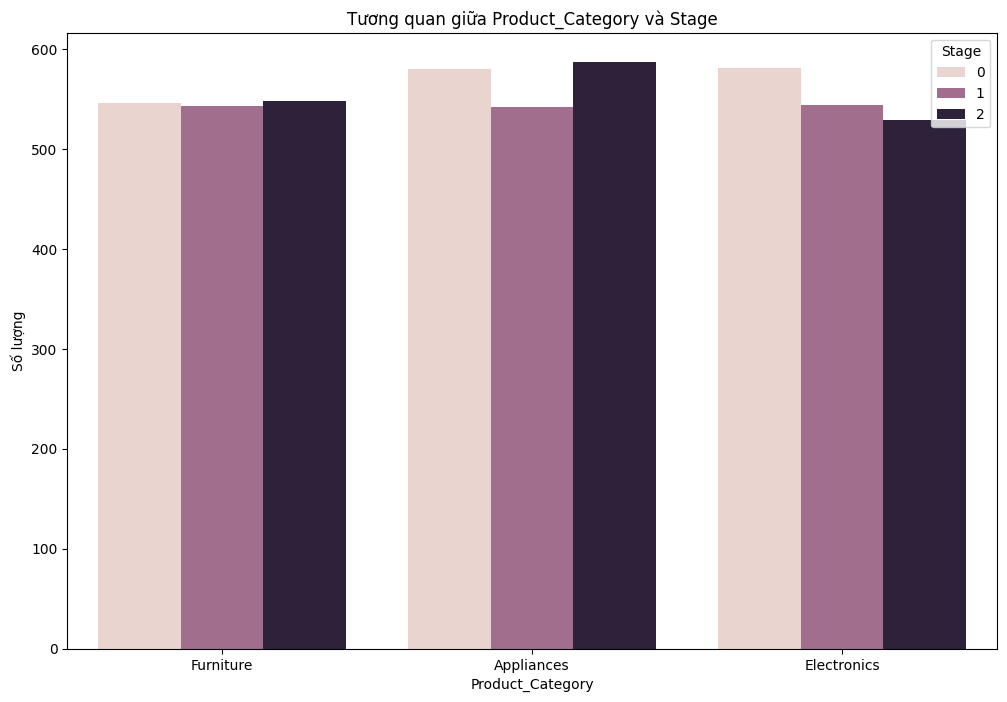

In [8]:
# Phân tích tương quan các thuộc tính phân loại (cat_features) và mục tiêu (Stage)
target = "Stage"

# Lấy danh sách các cột phân loại
cat_features = df.select_dtypes(include=["object"]).columns.tolist()

# Nếu có cột mục tiêu dạng object thì loại ra
for col in ["Stage", "stage", "STAGE", target]:
    if col in cat_features:
        cat_features.remove(col)

print("Các cột phân loại cần vẽ:", cat_features)

# Vẽ từng biểu đồ riêng
for col in cat_features:
    plt.figure(figsize=(12, 8))
    sns.countplot(data=df, x=col, hue=target)
    plt.title(f"Tương quan giữa {col} và Stage")
    plt.xlabel(col)
    plt.ylabel("Số lượng")
    plt.legend(title="Stage")
    plt.show()

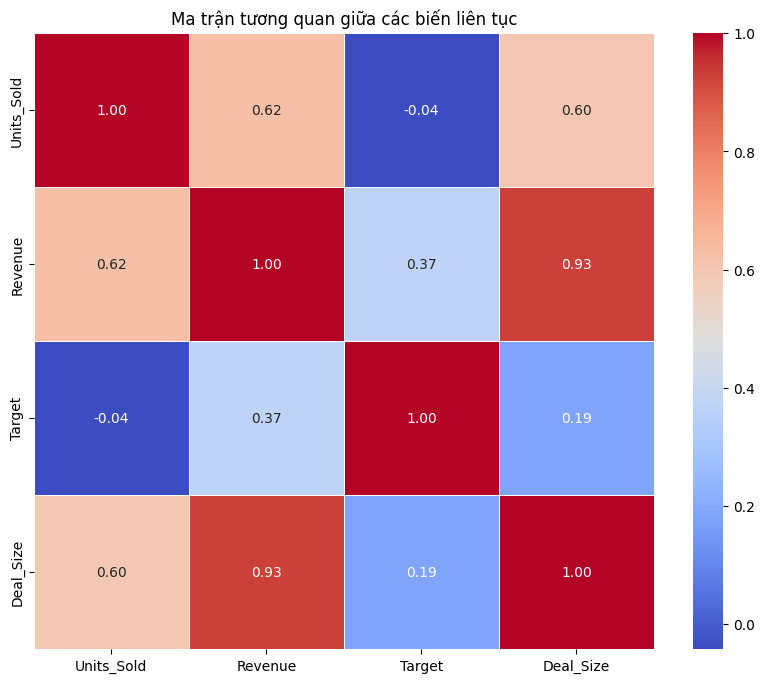

In [9]:
#Phân tích tương quan giữa các thuộc tính liên tục
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Stage', errors='ignore')
df[num_cols].head()
corr_matrix = df[num_cols].corr()
corr_matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=.5, cmap='coolwarm')
plt.title("Ma trận tương quan giữa các biến liên tục")
plt.show()


In [10]:
# Xóa các cột có khả năng gây data leakage
df = df.drop(columns=['Deal_Size','Revenue','Units_Sold'])

# Mã hóa Label Encoding cho các biến categorical
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# # Clip giá trị về khoảng [P1, P99] cho Units_Sold
# import numpy as np
# p1 = np.percentile(df['Units_Sold'], 1)
# p99 = np.percentile(df['Units_Sold'], 99)
# df['Units_Sold'] = df['Units_Sold'].clip(lower=p1, upper=p99)

# Kiểm tra
print("\n==== DỮ LIỆU SAU KHI LÀM SẠCH ====")
print(df.head())



==== DỮ LIỆU SAU KHI LÀM SẠCH ====
   Region  Country  Sales_Rep  Team  Customer_Segment  Product_Category  \
0       1        7          1     2                 0                 2   
1       2        1          0     1                 2                 0   
2       2        1          3     2                 1                 0   
3       0        3          4     1                 1                 0   
4       1        2          1     0                 1                 1   

   Stage  Target  Order_Year  Order_Month  Order_Day  
0      2    1447        2021            1          1  
1      1     875        2021            1          2  
2      1     277        2021            1          2  
3      1    1080        2021            1          2  
4      0     854        2021            1          2  


In [11]:
# Chia dữ liệu thành tập dữ liệu và kiểm tra

TARGET = "Stage"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Chia train - test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Đảm bảo kích thước dữ liệu đúng
print('Train set:', X_train.shape, y_train.shape)
print('Test set :', X_test.shape, y_test.shape)


Train set: (4000, 10) (4000,)
Test set : (1000, 10) (1000,)


In [12]:
# TimeSeriesSplit 5 fold và RandomizedSearchCV 50 thử nghiệm
# ===============================
# Scale features
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# ===============================
# Classification target
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

model = XGBClassifier(random_state=42)

# Tham số để search
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=50,          # 50 thử nghiệm
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

search.fit(X_train_scaled, y_train_enc)
best_model = search.best_estimator_

# Dự đoán
y_pred_enc = best_model.predict(X_test_scaled)
from sklearn.metrics import f1_score

f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")
f1_weighted = f1_score(y_test_enc, y_pred_enc, average="weighted")


# Metrics
print("Best params:", search.best_params_)
print("Accuracy:", accuracy_score(y_test_enc, y_pred_enc))
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_.astype(str)))
print(f"F1-score (macro)    : {f1_macro:.4f}")
print(f"F1-score (weighted) : {f1_weighted:.4f}")
from sklearn.metrics import confusion_matrix
import pandas as pd
# In Confusion Matrix
cm = confusion_matrix(y_test_enc, y_pred_enc)

# In dạng bảng cho dễ đọc (khuyên dùng)
cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

print("\nConfusion Matrix (table):")
print(cm_df)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Accuracy: 0.578

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.74      0.62       353
           1       0.61      0.88      0.72       315
           2       0.70      0.12      0.21       332

    accuracy                           0.58      1000
   macro avg       0.62      0.58      0.52      1000
weighted avg       0.61      0.58      0.51      1000

F1-score (macro)    : 0.5153
F1-score (weighted) : 0.5141

Confusion Matrix (table):
     0    1   2
0  262   76  15
1   37  276   2
2  190  102  40


In [17]:
# Lấy X_test gốc (chưa scale) để lưu cùng
X_test_df = X_test.copy()
X_test_df.reset_index(drop=True, inplace=True)

# Dự đoán
y_pred_enc_series = pd.Series(y_pred_enc, name="Predicted")
y_actual_series = pd.Series(le.inverse_transform(y_test_enc), name="Actual")

# Gộp lại
pred_df = pd.concat([X_test_df, y_actual_series, y_pred_enc_series], axis=1)

# Lưu ra CSV
pred_df.to_csv("/content/drive/MyDrive/Colab Notebooks/preds_XGBClassifier.csv", index=False)

print("Đã lưu dự đoán kèm tất cả feature và y_test ra CSV.")



Đã lưu dự đoán kèm tất cả feature và y_test ra CSV.


In [14]:
# Tạo thư mục lưu nếu chưa tồn tại
model_path = "/content/drive/MyDrive/Colab Notebooks/models/xgb_OLAP.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(best_model, model_path)

print(f"Model XGBoost đã lưu tại: {model_path}")


Model XGBoost đã lưu tại: /content/drive/MyDrive/Colab Notebooks/models/xgb_OLAP.pkl


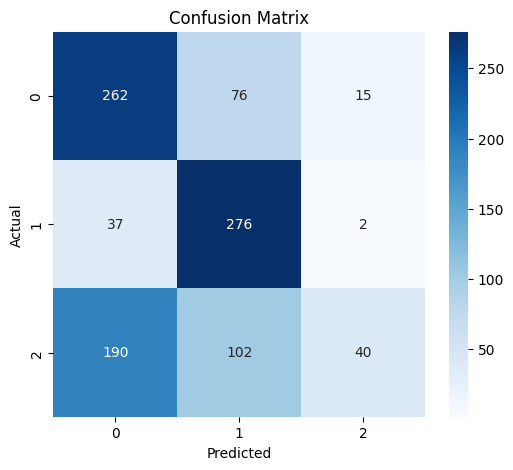

In [15]:
# ===============================
# Classification: Confusion Matrix
# ===============================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred_enc)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

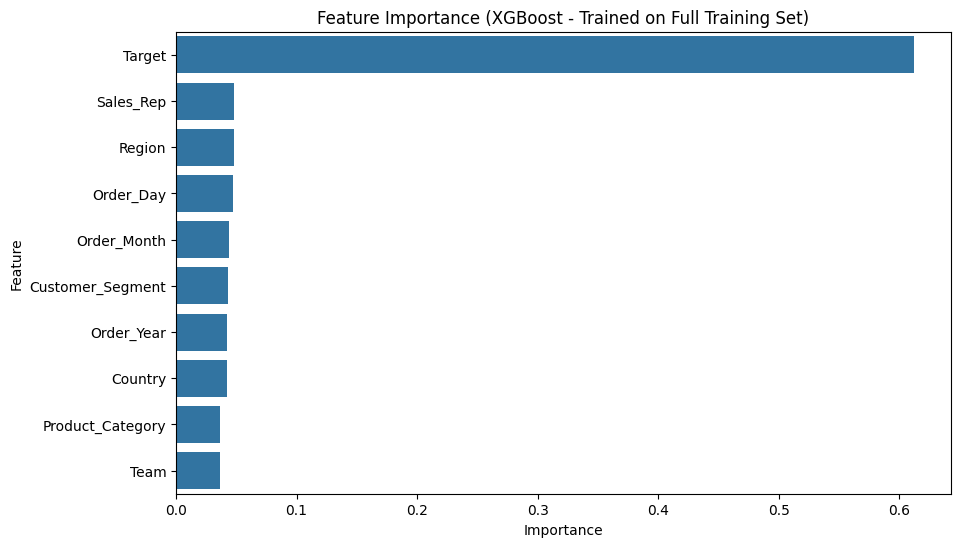

In [16]:
# Lấy feature importance từ model đã train
importances = best_model.feature_importances_

# Tạo DataFrame
fi = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Vẽ Feature Importance
plt.figure(figsize=(10, max(6, 0.3 * len(fi))))
sns.barplot(data=fi, x="Importance", y="Feature")
plt.title("Feature Importance (XGBoost - Trained on Full Training Set)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()
